In [1]:
%pip install gym torch numpy matplotlib -q

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch import Tensor

In [15]:
class PolicyNetwork(nn.Module):
    """
    A neural network policy used in the REINFORCE algorithm,
    mapping input states to a probability distribution over actions.

    Attributes:
        fc (nn.Sequential): A fully connected network with two linear layers,
                            ReLU activation, and Softmax at the output to produce
                            a probability distribution.
    """
    def __init__(self, input_dim: int, output_dim: int) -> None:
        """
        Initializes the policy network.

        Args:
            input_dim (int): The size of the input (number of state dimensions).
            output_dim (int): The number of possible actions.
        """
        super(PolicyNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim),
            nn.Softmax(dim=-1)  # Probability distribution over actions
        )

    def forward(self, x: Tensor) -> Tensor:
        """
        Performs a forward pass through the network.

        Args:
            x (Tensor): The input state tensor with shape (batch_size, input_dim).

        Returns:
            Tensor: A probability distribution over actions with shape (batch_size, output_dim).
        """
        return self.fc(x)

In [24]:
import torch
import torch.nn as nn
from torch.distributions import Categorical
from typing import Tuple

def select_action(policy: nn.Module, state: torch.Tensor) -> Tuple[int, torch.Tensor]:
    """
    Selects an action from the policy network based on the current state using stochastic sampling.

    Instead of always choosing the action with the highest probability, this function samples
    an action from the probability distribution output by the policy network. This introduces
    randomness and encourages exploration in Reinforcement Learning.

    Args:
        policy (nn.Module): The policy network, which takes the state as input and returns
                            a probability distribution over possible actions.
        state (torch.Tensor): The current state of the environment, represented as a tensor.

    Returns:
        Tuple[int, torch.Tensor]: A tuple containing:
            - The selected action (int).
            - The log-probability of the selected action (torch.Tensor),
              which is used to update the policy in the REINFORCE algorithm.
    """
    state = torch.tensor(state, dtype=torch.float32).unsqueeze(0) # Ensure batch size = 1
    probs = policy(state)  # Get probability distribution from the policy network
    action_dist = Categorical(probs)  # Create a categorical distribution
    action = action_dist.sample()  # Sample an action
    return action.item(), action_dist.log_prob(action)  # Return the action and its log-probability

In [21]:
import torch
from typing import List

def compute_discounted_rewards(rewards: List[float], gamma: float = 0.99) -> torch.Tensor:
    """
    Computes the discounted rewards for a sequence of rewards in a reinforcement learning episode.

    The discounted reward at each time step `t` is calculated using the formula:

        G_t = R_t + γ * G_{t+1}

    where:
        - `G_t` is the discounted return at time `t`.
        - `R_t` is the immediate reward at time `t`.
        - `γ` (gamma) is the discount factor, controlling the importance of future rewards.

    This function iterates over the rewards in reverse order to efficiently compute the discounted
    returns for an entire episode.

    Args:
        rewards (List[float]): A list of rewards obtained at each time step in an episode.
        gamma (float, optional): The discount factor (default is 0.99).

    Returns:
        torch.Tensor: A tensor of discounted rewards, with the same length as `rewards`.

    Example:
        >>> rewards = [1, 0, -1, 2]
        >>> compute_discounted_rewards(rewards, gamma=0.9)
        tensor([ 0.4390, -0.49,  1.1,  2. ])
    """
    discounted_rewards = []
    total_reward = 0
    for r in reversed(rewards):  # Iterate from the last reward to the first
        total_reward = r + gamma * total_reward  # Compute discounted return
        discounted_rewards.insert(0, total_reward)  # Insert at the beginning
    return torch.tensor(discounted_rewards, dtype=torch.float32)  # Convert to tensor

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import gym
from typing import List

def train_policy_gradient(
    env: gym.Env,
    policy: nn.Module,
    optimizer: optim.Optimizer,
    num_episodes: int = 500,
    gamma: float = 0.99
) -> List[float]:
    """
    Trains a policy network using the REINFORCE algorithm with Monte Carlo policy updates.

    Args:
        env (gym.Env): The reinforcement learning environment.
        policy (nn.Module): The policy network that outputs action probabilities.
        optimizer (optim.Optimizer): The optimizer for updating the policy network.
        num_episodes (int, optional): The number of episodes to train. Defaults to 500.
        gamma (float, optional): The discount factor for future rewards. Defaults to 0.99.

    Returns:
        List[float]: A list containing the total rewards for each episode.

    Workflow:
        1. Reset the environment at the start of each episode.
        2. Collect log probabilities and rewards for each step until the episode ends.
        3. Compute discounted rewards to properly weigh rewards over time.
        4. Normalize rewards to stabilize training.
        5. Compute the policy loss using the log probabilities and discounted rewards.
        6. Perform a gradient update to improve the policy.
        7. Store and return the total rewards per episode.

    Notes:
        - The function handles different versions of OpenAI Gym's `reset()` and `step()` API.
        - Rewards are normalized to reduce variance and improve stability.
    """
    reward_history = []

    for episode in range(num_episodes):
        state = env.reset()
        if isinstance(state, tuple):  # Handle different Gym versions
            state = state[0]

        log_probs = []
        rewards = []

        done = False
        while not done:
            action, log_prob = select_action(policy, state)
            step_result = env.step(action)

            # Handle Gym's different step API versions
            if len(step_result) == 5:
                next_state, reward, terminated, truncated, _ = step_result
                done = terminated or truncated  # Handle different termination conditions
            else:
                next_state, reward, done, _ = step_result  # Older versions

            log_probs.append(log_prob)
            rewards.append(reward)

            state = next_state

        # Compute discounted rewards
        discounted_rewards = compute_discounted_rewards(rewards, gamma)

        # Normalize rewards to reduce variance
        discounted_rewards = (discounted_rewards - discounted_rewards.mean()) / (discounted_rewards.std() + 1e-9)

        # Compute policy loss
        policy_loss = []
        for log_prob, reward in zip(log_probs, discounted_rewards):
            policy_loss.append(-log_prob * reward)
        policy_loss = torch.stack(policy_loss).sum()

        # Update policy
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        total_episode_reward = sum(rewards)
        reward_history.append(total_episode_reward)

        if (episode + 1) % 50 == 0:
            print(f"Episode {episode+1}, Total Reward: {total_episode_reward}")

    return reward_history

In [ ]:
env = gym.make("CartPole-v1")
policy = PolicyNetwork(env.observation_space.shape[0], env.action_space.n) # type: ignore
optimizer = optim.Adam(policy.parameters(), lr=0.01)

reward_history = train_policy_gradient(env, policy, optimizer, num_episodes=500)


Episode 50, Total Reward: 36.0
Episode 100, Total Reward: 59.0
Episode 150, Total Reward: 500.0
Episode 200, Total Reward: 500.0
Episode 250, Total Reward: 500.0
Episode 300, Total Reward: 500.0
Episode 350, Total Reward: 500.0
Episode 400, Total Reward: 279.0
Episode 450, Total Reward: 67.0
Episode 500, Total Reward: 121.0


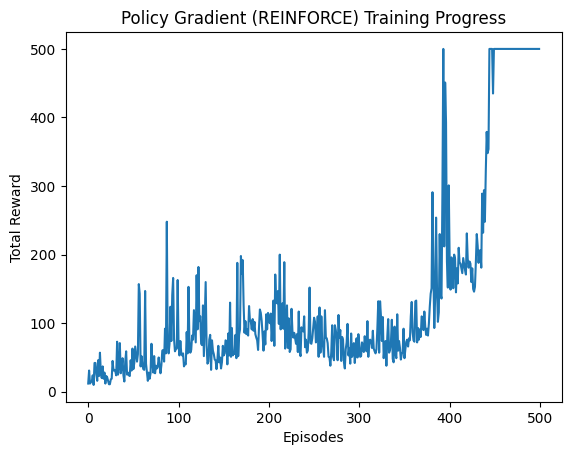

In [27]:
plt.plot(reward_history)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Policy Gradient (REINFORCE) Training Progress")
plt.show()

# **Giải thích Code**

Hàm `train_policy_gradient` triển khai thuật toán **REINFORCE**, một phương pháp tối ưu hóa tham số chính sách bằng cách sử dụng **cập nhật Monte Carlo**.  

Quá trình huấn luyện bắt đầu bằng việc **khởi tạo môi trường**, sau đó lặp qua nhiều **episode** để thu thập dữ liệu về **trạng thái, hành động và phần thưởng**.  

- Trong mỗi bước của một **episode**, một hành động được lấy mẫu từ **policy network**, thực thi trong môi trường, và phần thưởng tương ứng được lưu lại.  
- Khi một **episode** kết thúc, phần thưởng chiết khấu (**discounted rewards**) được tính bằng hàm `compute_discounted_rewards`, đảm bảo rằng phần thưởng trong tương lai cũng góp phần vào quá trình cập nhật chính sách.  
- Sau đó, các phần thưởng này được **chuẩn hóa** nhằm giảm phương sai (**variance**), giúp quá trình huấn luyện ổn định hơn.  

Hàm **mất mát chính sách (policy loss)** được tính bằng cách **nhân log-probability của các hành động với phần thưởng chiết khấu tương ứng**.  
Cuối cùng, chính sách được cập nhật bằng **gradient descent**, giúp tối đa hóa phần thưởng kỳ vọng bằng cách tăng cường các hành động dẫn đến kết quả tốt hơn.  

---

## **Kết quả mong đợi & Giải thích**
Biểu đồ huấn luyện thể hiện **sự thay đổi của tổng phần thưởng mỗi episode trong 500 tập huấn luyện**.  

- **Ban đầu**, agent hoạt động kém hiệu quả, thể hiện qua giá trị phần thưởng thấp trong các episode đầu tiên .  
- Tuy nhiên, khi quá trình huấn luyện diễn ra, agent dần **học được các chiến lược hiệu quả hơn**, dẫn đến mức phần thưởng cao hơn .  
- Hiệu suất đạt đỉnh khi agent **giữ thăng bằng cây cột tối đa thời gian**, đạt **500 điểm phần thưởng mỗi episode** .  

Tuy nhiên, vẫn có **sự mất ổn định**, thể hiện qua **sự sụt giảm mạnh về phần thưởng**.  
Nguyên nhân của hiện tượng này là **phương sai cao của phương pháp Policy Gradient (PG)**, khi một số cập nhật có thể dẫn đến chính sách kém hiệu quả trước khi dần ổn định trở lại.  

---

## **Giải thích chi tiết**
### **Vì sao cần discounted rewards?**  
- Giúp agent **tập trung vào mục tiêu dài hạn**, không chỉ tối ưu phần thưởng tức thời.  

### **Tại sao phải chuẩn hóa phần thưởng?**  
- Giảm phương sai giúp **gradient descent hội tụ nhanh hơn**.  

### **Vì sao có sự sụt giảm phần thưởng trong quá trình học?**  
- Thuật toán Policy Gradient **không ổn định** như các phương pháp khác (VD: PPO), nên có thể xuất hiện **các bước cập nhật khiến policy tệ hơn trước khi dần cải thiện**.  

---

## **Tóm tắt**
- **REINFORCE cập nhật policy bằng Monte Carlo, dựa trên dữ liệu thu thập từ nhiều episode.**  
- **Discounted rewards giúp agent học cách tối ưu phần thưởng dài hạn.**  
- **Huấn luyện có thể không ổn định do phương sai cao của Policy Gradient.**  
- **Hiệu suất tăng dần, nhưng có thể gặp các giai đoạn suy giảm tạm thời trước khi ổn định.**  
